In [1]:
# ==========================================================
# Imports
# ==========================================================

from pathlib import Path

import numpy as np
import torch

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
PROJECT_PATH = Path("/content/drive/MyDrive/UAH_Project")

DATASET_PATH = (
    PROJECT_PATH
    / "datasets"
    / "processed"
    / "uah_dataset.npz"
)

sensor_data = np.load(DATASET_PATH)

X = sensor_data["X"]
y = sensor_data["y"]
groups = sensor_data["groups"]

print(X.shape)

(30676, 120, 13)


In [4]:
unique_groups = np.unique(groups)

trip_labels = np.array([
    y[groups == trip][0]
    for trip in unique_groups
])

train_groups, test_groups = train_test_split(
    unique_groups,
    test_size=0.20,
    random_state=42,
    stratify=trip_labels,
)

In [5]:
train_mask = np.isin(
    groups,
    train_groups,
)

test_mask = np.isin(
    groups,
    test_groups,
)

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

In [6]:
print(X_train.shape)
print(X_test.shape)

(24725, 120, 13)
(5951, 120, 13)


In [7]:
import torch
from torch.utils.data import Dataset


class SensorDataset(Dataset):

    def __init__(self, X, y):

        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):

        return self.X[idx], self.y[idx]

In [8]:
train_dataset = SensorDataset(
    X_train,
    y_train,
)

test_dataset = SensorDataset(
    X_test,
    y_test,
)

print(len(train_dataset))
print(len(test_dataset))

24725
5951


In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
)

print(len(train_loader))
print(len(test_loader))

773
186


In [10]:
sensor, label = next(iter(train_loader))

print(sensor.shape)
print(label.shape)

torch.Size([32, 120, 13])
torch.Size([32])


In [11]:
import sys

SRC = "/content/drive/MyDrive/UAH_Project/src"

if SRC not in sys.path:
    sys.path.insert(0, SRC)

In [13]:
import lstm_model

print(dir(lstm_model))

['LSTMClassifier', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'nn', 'torch']


In [14]:
import importlib

import lstm_model
import trainer

importlib.reload(lstm_model)
importlib.reload(trainer)

from lstm_model import LSTMClassifier
from trainer import fit

In [15]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = LSTMClassifier().to(device)

print(model)

LSTMClassifier(
  (lstm): LSTM(13, 64, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [16]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train,
)

weights = torch.FloatTensor(
    class_weights
).to(device)

print(class_weights)

[0.82121031 0.98690776 1.30035763]


In [17]:
criterion = torch.nn.CrossEntropyLoss(
    weight=weights
)

In [18]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
)

In [19]:
EPOCHS = 20
PATIENCE = 3

In [20]:
history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=EPOCHS,
    patience=PATIENCE,
)

Epoch 1/20 | Train Loss: 1.0181 | Train Acc: 0.4466 | Val Loss: 1.0285 | Val Acc: 0.4534
Epoch 2/20 | Train Loss: 0.8774 | Train Acc: 0.5922 | Val Loss: 1.0239 | Val Acc: 0.4492
Epoch 3/20 | Train Loss: 0.8153 | Train Acc: 0.6255 | Val Loss: 0.9845 | Val Acc: 0.4759
Epoch 4/20 | Train Loss: 0.7764 | Train Acc: 0.6430 | Val Loss: 0.9878 | Val Acc: 0.4902
Epoch 5/20 | Train Loss: 0.7450 | Train Acc: 0.6574 | Val Loss: 0.9620 | Val Acc: 0.5081
Epoch 6/20 | Train Loss: 0.7226 | Train Acc: 0.6691 | Val Loss: 0.9567 | Val Acc: 0.5112
Epoch 7/20 | Train Loss: 0.6977 | Train Acc: 0.6786 | Val Loss: 0.9585 | Val Acc: 0.5224
Epoch 8/20 | Train Loss: 0.6800 | Train Acc: 0.6922 | Val Loss: 1.0471 | Val Acc: 0.4950
Epoch 9/20 | Train Loss: 0.6635 | Train Acc: 0.7036 | Val Loss: 1.0436 | Val Acc: 0.4962
Epoch 10/20 | Train Loss: 0.6522 | Train Acc: 0.7094 | Val Loss: 0.9625 | Val Acc: 0.5266
Epoch 11/20 | Train Loss: 0.6359 | Train Acc: 0.7114 | Val Loss: 1.0319 | Val Acc: 0.4979
Epoch 12/20 | Train

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

model.eval()

y_true = []
y_pred = []

with torch.no_grad():

    for sensor, labels in test_loader:

        sensor = sensor.to(device)

        outputs = model(sensor)

        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

In [22]:
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred, average='weighted'):.4f}")
print(f"Recall   : {recall_score(y_true, y_pred, average='weighted'):.4f}")
print(f"F1 Score : {f1_score(y_true, y_pred, average='weighted'):.4f}")

Accuracy : 0.5266
Precision: 0.5716
Recall   : 0.5266
F1 Score : 0.5270


In [23]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "NORMAL",
            "DROWSY",
            "AGGRESSIVE",
        ]
    )
)

              precision    recall  f1-score   support

      NORMAL       0.59      0.36      0.45      2955
      DROWSY       0.34      0.59      0.43      1495
  AGGRESSIVE       0.76      0.78      0.77      1501

    accuracy                           0.53      5951
   macro avg       0.56      0.58      0.55      5951
weighted avg       0.57      0.53      0.53      5951



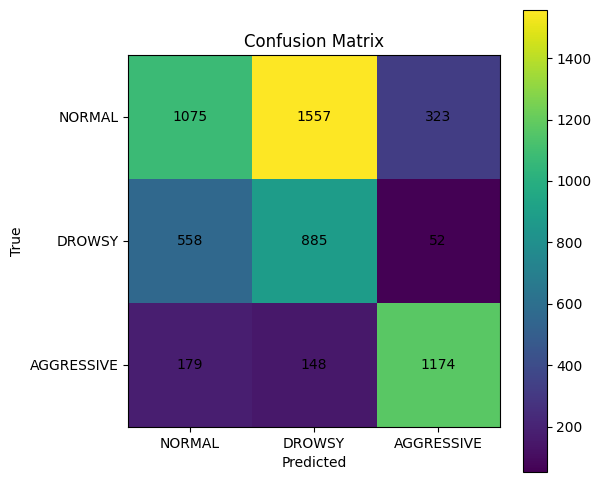

In [24]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,6))

plt.imshow(cm)

plt.title("Confusion Matrix")

plt.colorbar()

plt.xticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.yticks(
    [0,1,2],
    ["NORMAL","DROWSY","AGGRESSIVE"]
)

plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(3):
    for j in range(3):
        plt.text(
            j,
            i,
            cm[i,j],
            ha="center",
            va="center",
        )

plt.show()

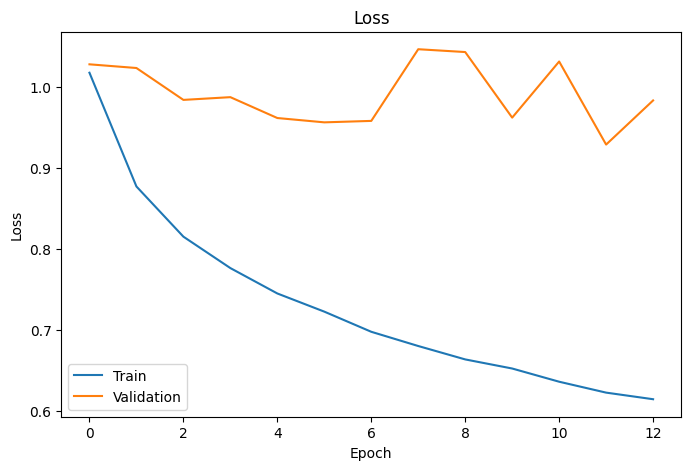

In [25]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train")
plt.plot(history["val_loss"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss")

plt.legend()

plt.show()

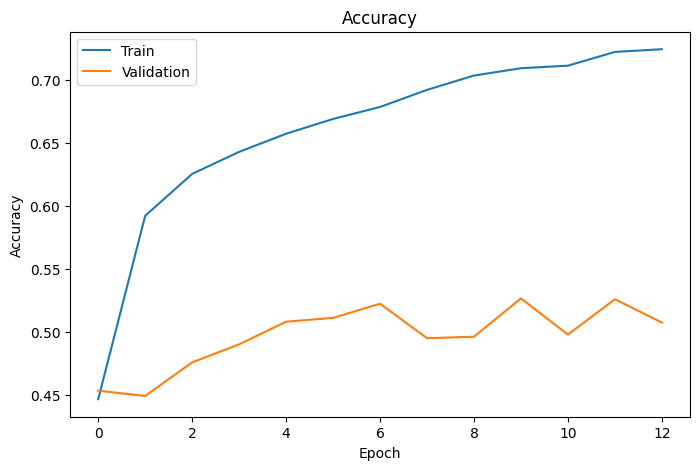

In [26]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train")
plt.plot(history["val_acc"], label="Validation")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy")

plt.legend()

plt.show()